In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline

import os

In [4]:
os.chdir(r"C:\Users\Student\Desktop")


In [19]:
Использовать "pd.read_csv" для чтения файла.

In [20]:
df.head()


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.75,1,1,0,0,0.33,1,0,0,0,0,0,0,0.66,1
1,0.25,0,1,0,0,0.33,0,0,0,0,1,0,1,0.66,1
2,0.25,0,1,0,0,0.66,0,0,0,0,1,0,0,0.33,1
3,0.25,0,1,0,1,0.33,1,0,1,1,0,1,1,0.33,1
4,1.00,1,1,1,0,0.33,1,0,1,1,0,1,1,0.66,1


См. [документацию]( https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html).

In [21]:
print(df)

       1  2  3  4  5     6  7  8  9  10  11  12  13    14  15
0   0.75  1  1  0  0  0.33  1  0  0   0   0   0   0  0.66   1
1   0.25  0  1  0  0  0.33  0  0  0   0   1   0   1  0.66   1
2   0.25  0  1  0  0  0.66  0  0  0   0   1   0   0  0.33   1
3   0.25  0  1  0  1  0.33  1  0  1   1   0   1   1  0.33   1
4   1.00  1  1  1  0  0.33  1  0  1   1   0   1   1  0.66   1
5   0.75  0  1  0  0  0.33  1  0  0   0   0   0   0  0.66   1
6   0.50  0  1  1  0  0.66  0  1  0   0   0   1   1  0.66   1
7   0.50  0  1  0  0  0.33  0  1  1   0   0   0   1  0.33   1
8   0.50  0  1  0  0  0.66  0  0  0   0   1   0   0  0.33   1
9   0.50  0  0  1  0  0.00  1  0  1   0   0   0   1  0.33   0
10  0.75  0  1  0  0  0.33  1  0  1   0   0   0   1  0.66   1
11  0.25  0  0  1  0  0.00  0  0  0   0   1   1   1  0.66   0
12  0.25  0  1  0  0  0.33  1  0  0   0   0   0   0  0.33   1
13  0.50  0  1  1  0  1.00  1  0  0   0   0   0   0  0.33   1
14  0.25  0  1  0  0  0.33  0  0  0   0   1   0   0  0.66   1
15  0.25

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Объект, в котором будет хранится информация о последовательном слиянии кластеров
link = linkage(df, ' ', ' ')

In [23]:
link[:5]

array([[ 2.        ,  8.        ,  0.25      ,  2.        ],
       [ 1.        , 24.        ,  0.33      ,  2.        ],
       [21.        , 28.        ,  0.41400483,  2.        ],
       [14.        , 30.        ,  0.5578829 ,  3.        ],
       [ 5.        , 12.        ,  0.59908263,  2.        ]])

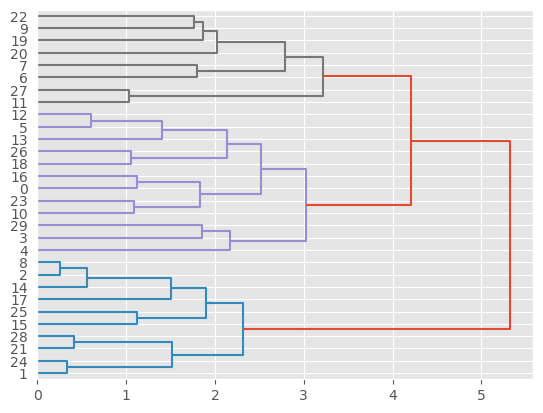

In [30]:
# Функция для построения дендрограммы
dn = dendrogram(link, orientation = "right")

In [41]:
# Останавливаем объединение, если расстояние между кластерами превышает 3
df['cluster'] = fcluster(link, 4, criterion='distance')

In [42]:
df.groupby('cluster').mean()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
cluster,,,,,,,,,,,,,,,
1,0.4750,0.000000,1.000000,0.000000,0.100000,0.396000,0.000,0.000,0.000000,0.000,1.00,0.200000,0.500000,0.429000,0.80
2,0.5625,0.333333,0.916667,0.333333,0.083333,0.414167,1.000,0.000,0.333333,0.250,0.00,0.166667,0.666667,0.578333,1.00
3,0.5625,0.000000,0.625000,0.875000,0.000000,0.372500,0.375,0.375,0.625000,0.125,0.25,0.375000,0.875000,0.536250,0.25


In [43]:
df.groupby('cluster').size()

cluster
1    10
2    12
3     8
dtype: int64